# 03 — 失败案例分析 & 消融结果汇总

本 Notebook 使用最终评测产物进行分析，不重新运行模型推理。内容包括：
1. 从 full RefCOCO validation 结果中筛选失败案例并分类
2. 典型失败案例可视化
3. 汇总已有 prompt ablation、threshold sweep 和 protocol comparison 结果

默认读取路径与最终报告一致。

In [1]:
%matplotlib inline
import sys, random
from pathlib import Path

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from PIL import Image
from IPython.display import display

from src.utils.io import load_json
from src.analysis.failure_miner import mine_failures, summarize_failures, select_examples

random.seed(42)
print('准备就绪')

准备就绪


## 1. 失败案例统计

In [2]:
PRED_FILE = Path('../results/refcoco_gdino/refcoco_validation_predictions.json')

per_sample = load_json(PRED_FILE)
failures = mine_failures(per_sample)
summary = summarize_failures(failures)

n_total = len(per_sample)
n_fail = len(failures)
acc = (n_total - n_fail) / n_total * 100

print(f'RefCOCO validation full split')
print(f'总样本：{n_total}，失败：{n_fail}，Acc@0.5 = {acc:.2f}%')
print('失败类型分布：', summary)

RefCOCO validation full split
总样本：10834，失败：5325，Acc@0.5 = 50.85%
失败类型分布： {'unknown': 4586, 'lang_ambig': 718, 'rare_word': 24}


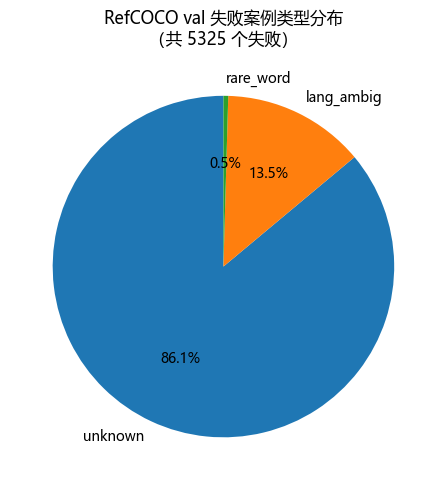

In [3]:
# 失败类型饼图
labels = list(summary.keys())
sizes  = list(summary.values())

fig, ax = plt.subplots(figsize=(7, 5))
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
ax.set_title(f'RefCOCO val 失败案例类型分布\n（共 {n_fail} 个失败）')
plt.tight_layout()
plt.savefig('figures/failure_type_pie.png', dpi=120)
plt.show()

**Failure type distribution**

![Failure type distribution](figures/failure_type_pie.png)

## 2. 典型失败案例可视化

In [4]:
def show_failure_grid(examples, title='失败案例', cols=5):
    if not examples:
        fig, ax = plt.subplots(figsize=(8, 2))
        ax.text(0.5, 0.5, 'No examples found for this failure type.', ha='center', va='center')
        ax.axis('off')
        return fig

    rows = (len(examples) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.5))
    axes_arr = np.array(axes, dtype=object).reshape(-1)

    for ax, sample in zip(axes_arr, examples):
        img_path = Path(sample['img_path'])
        if not img_path.is_absolute():
            img_path = ROOT / img_path
        try:
            pil_img = Image.open(img_path).convert('RGB')
        except Exception as exc:
            ax.text(0.5, 0.5, f'Image load failed\n{img_path}\n{exc}', ha='center', va='center', fontsize=7)
            ax.axis('off')
            continue

        ax.imshow(pil_img)
        ax.set_title(
            f"IoU={sample.get('iou',0):.2f}  score={sample.get('pred_score',0):.2f}\n"
            f"[{', '.join(sample.get('failure_types',['?']))}]\n"
            f"{sample.get('expr','')[:45]}",
            fontsize=7,
        )
        ax.axis('off')
        if sample.get('pred_box'):
            x1, y1, x2, y2 = sample['pred_box']
            ax.add_patch(mpatches.Rectangle((x1, y1), x2-x1, y2-y1, lw=2, ec='red', fc='none'))
        if sample.get('gt_box'):
            x1, y1, x2, y2 = sample['gt_box']
            ax.add_patch(mpatches.Rectangle((x1, y1), x2-x1, y2-y1, lw=2, ec='lime', fc='none', ls='--'))

    for ax in axes_arr[len(examples):]:
        ax.set_visible(False)
    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    return fig

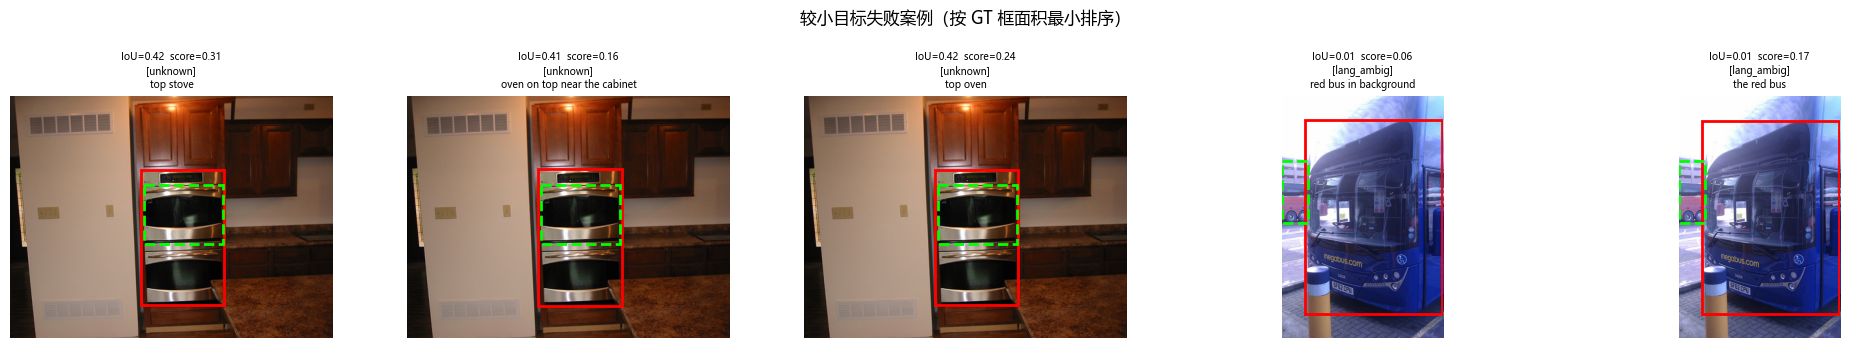

In [5]:
# 较小目标失败：RefCOCO full split 中没有满足 COCO small-object 绝对阈值 (area < 32^2) 的失败样本。
# 因此这里按 GT 框面积升序选取失败样本，展示“相对较小目标”的定位失败。
def select_smallest_gt_failures(failures, n=5):
    ranked = []
    for sample in failures:
        gt_box = sample.get('gt_box') or sample.get('gt_box_xyxy')
        if not gt_box or not sample.get('pred_box'):
            continue
        x1, y1, x2, y2 = gt_box
        area = max(0, x2 - x1) * max(0, y2 - y1)
        ranked.append((area, sample))
    return [sample for _, sample in sorted(ranked, key=lambda item: item[0])[:n]]

small_obj_fails = select_smallest_gt_failures(failures, n=5)
if small_obj_fails:
    fig = show_failure_grid(small_obj_fails, '较小目标失败案例（按 GT 框面积最小排序）')
    plt.savefig('figures/failure_small_obj.png', dpi=120)
    plt.show()
else:
    fig = show_failure_grid([], '较小目标失败案例')
    plt.savefig('figures/failure_small_obj.png', dpi=120)
    plt.show()

**Smaller-object failures**

No failed RefCOCO validation sample satisfies the strict COCO small-object threshold (area < 32^2). The visualization below therefore uses the five failed samples with the smallest ground-truth box area to show relatively small-object localization failures.

![Smaller-object failures](figures/failure_small_obj.png)

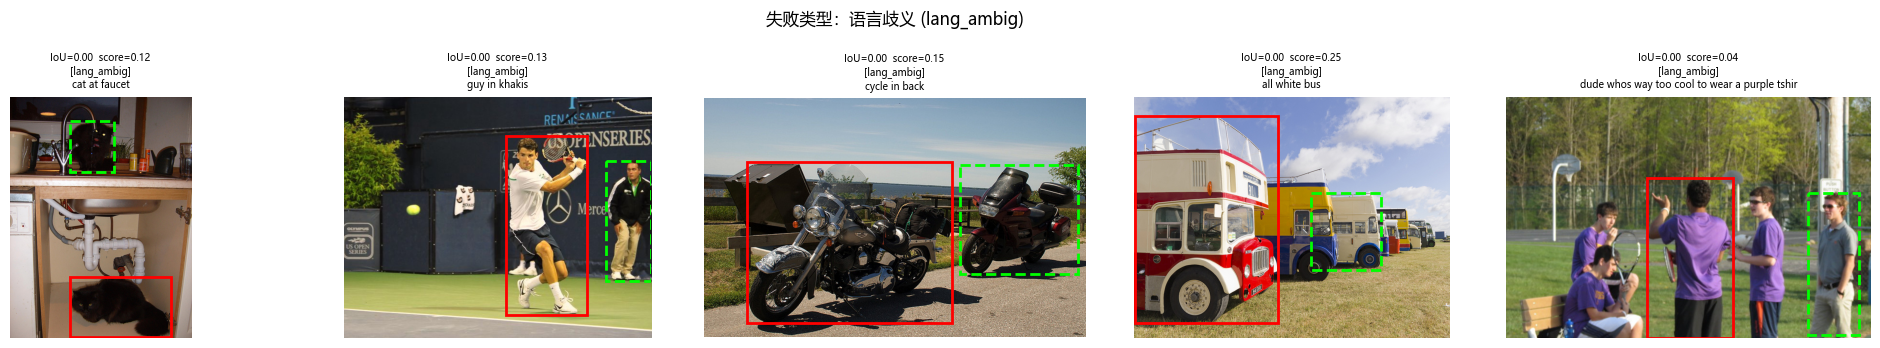

In [6]:
# 语言歧义失败
lang_fails = select_examples(failures, failure_type='lang_ambig', n=5)
if lang_fails:
    fig = show_failure_grid(lang_fails, '失败类型：语言歧义 (lang_ambig)')
    plt.savefig('figures/failure_lang_ambig.png', dpi=120)
    plt.show()

**Language ambiguity failures**

![Language ambiguity failures](figures/failure_lang_ambig.png)

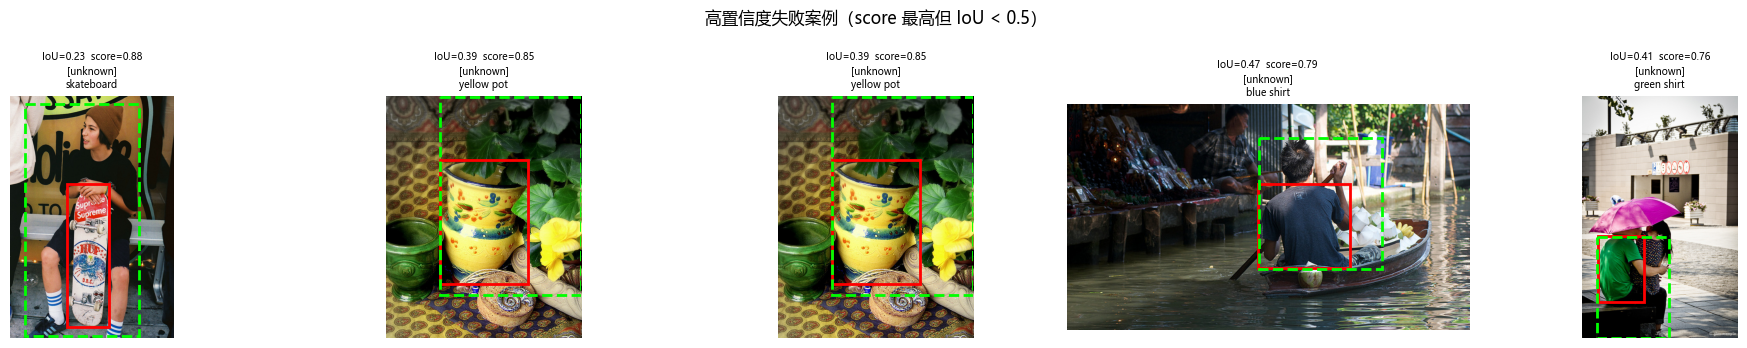

In [7]:
# 高置信度但失败（模型最自信的错误案例）
confident_fails = select_examples(failures, n=5, sort_by='score_desc')
if confident_fails:
    fig = show_failure_grid(confident_fails, '高置信度失败案例（score 最高但 IoU < 0.5）')
    plt.savefig('figures/failure_confident.png', dpi=120)
    plt.show()

**High-confidence failures**

![High-confidence failures](figures/failure_confident.png)

## 3. 消融与协议检查结果

本节直接读取已经完成的实验结果，避免在 notebook 中重新跑模型。

In [8]:
# OVD prompt ablation：读取已有结果。
ablation_results = load_json('../results/coco/ablation_prompt.json')

templates = ['{name}', 'a {name}', 'a photo of a {name}']
ovd_rows = []
for tmpl in templates:
    m = ablation_results[tmpl]
    ovd_rows.append({
        'Prompt template': tmpl,
        'mAP': f"{m['mAP']*100:.2f}",
        'AP50': f"{m['AP50']*100:.2f}",
        'AP75': f"{m['AP75']*100:.2f}",
        'Predictions': m['n_preds'],
        'Description': m.get('desc', ''),
    })

print('=== OVD Prompt Ablation ===')
display(pd.DataFrame(ovd_rows))

=== OVD Prompt Ablation ===


,Prompt template,mAP,AP50,AP75,Predictions,Description
0,{name},47.05,58.80,50.34,2731,直接类别名
1,a {name},17.56,24.21,19.97,1675,加不定冠词
2,a photo of a {name},5.24,6.33,6.00,185,CLIP 风格


In [9]:
# VG threshold sweep：读取 500-sample subset 最佳结果。
best_threshold = load_json('../results/exp_2026-05-23_vg_sweep/best_subset.json')
threshold_df = pd.DataFrame([{
    'box_threshold': best_threshold['box_threshold'],
    'text_threshold': best_threshold['text_threshold'],
    'Acc@0.5': f"{best_threshold['acc']*100:.2f}%",
    'hits/total': f"{best_threshold['n_hit']} / {best_threshold['n_total']}",
}])
print('=== VG Threshold Sweep Best Subset ===')
display(threshold_df)

=== VG Threshold Sweep Best Subset ===


,box_threshold,text_threshold,Acc@0.5,hits/total
0,0.05,0.05,52.20%,261 / 500


In [10]:
# VG protocol comparison：semantic vs argmax_official。
protocol = load_json('../results/exp_2026-06-15_vg_protocol/protocol_comparison.json')
rows = []
for name, result in protocol['results'].items():
    rows.append({
        'strategy': name,
        'Acc@1': f"{result['acc_at_1']*100:.2f}%",
        'Acc@5': f"{result['acc_at_5']*100:.2f}%",
        'Acc@10': f"{result['acc_at_10']*100:.2f}%",
        'hits/total': f"{result['n_hit']} / {result['n_total']}",
    })
print('=== VG Protocol Comparison ===')
display(pd.DataFrame(rows))
print(f"argmax_official - semantic: {protocol['delta_argmax_minus_semantic_pp']:.2f} percentage points")

=== VG Protocol Comparison ===


,strategy,Acc@1,Acc@5,Acc@10,hits/total
0,semantic,52.20%,89.60%,95.60%,261 / 500
1,argmax_official,52.60%,89.60%,95.60%,263 / 500


argmax_official - semantic: 0.40 percentage points


In [11]:
# 汇总结论，供报告直接引用。
print('结论摘要：')
print('- OVD prompt ablation 中，直接类别名 `{name}` 最好：mAP 47.05, AP50 58.80。')
print('- 更长 prompt 会占用 BERT token budget，导致 concat-token COCO prompt 中后续类别对齐变差。')
print('- VG 最佳阈值为 box=0.05, text=0.05；500-sample subset Acc@0.5 为 52.20%。')
print('- semantic 与 argmax_official 的 Acc@1 差异仅 0.4 个百分点，说明候选框质量比选择规则更关键。')

结论摘要：
- OVD prompt ablation 中，直接类别名 `{name}` 最好：mAP 47.05, AP50 58.80。
- 更长 prompt 会占用 BERT token budget，导致 concat-token COCO prompt 中后续类别对齐变差。
- VG 最佳阈值为 box=0.05, text=0.05；500-sample subset Acc@0.5 为 52.20%。
- semantic 与 argmax_official 的 Acc@1 差异仅 0.4 个百分点，说明候选框质量比选择规则更关键。
